In [42]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# Data Structure Inspection

This section provides utility functions to inspect the structure of your dataset, including shape, datatypes, duplicate checks, and a preview of the data.

In [43]:
def display_shape_and_dtypes(df):
    """Display the shape and data types of the DataFrame."""
    print("Shape:", df.shape)
    print("\nData Types:\n", df.dtypes)


def check_duplicates(df, subset=None):
    """Check for duplicate rows and duplicate IDs/keys (if subset provided)."""
    n_dupes = df.duplicated().sum()
    print(f"Duplicate rows: {n_dupes}")
    if subset is not None:
        n_dupes_key = df.duplicated(subset=subset).sum()
        print(f"Duplicate rows by {subset}: {n_dupes_key}")

from IPython.display import display

def display_head(df, n=5):
    """Display the first n rows of the DataFrame using a nice box."""
    display(df.head(n))


In [44]:
# Call the data structure inspection functions
print('--- Shape and Data Types ---')
display_shape_and_dtypes(df)

print('\n--- Duplicate Check (all rows) ---')
check_duplicates(df)

print('\n--- Data Preview (head) ---')
display_head(df, n=5)


--- Shape and Data Types ---
Shape: (150, 6)

Data Types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species               object
dtype: object

--- Duplicate Check (all rows) ---
Duplicate rows: 1

--- Data Preview (head) ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [45]:
# 1. Output missing data by column (count and percent)
def output_missing_by_column(df):
    missing_count = df.isnull().sum()
    missing_percent = df.isnull().mean() * 100
    print(pd.DataFrame({'Missing Count': missing_count, 'Missing Percent': missing_percent.round(2)}))

# 2. Check for sentinel values (e.g., -1, 0, 'N/A', etc.)
def check_sentinel_values(df, sentinels=None):
    if sentinels is None:
        sentinels = [-1, 0, "N/A", "n/a", "NA", "na", "unknown", "Unknown", "NONE", "None", ""]
    for col in df.columns:
        for sentinel in sentinels:
            count = (df[col] == sentinel).sum()
            if count > 0:
                print(f"Column '{col}' has {count} occurrences of sentinel value: {repr(sentinel)}")

# Call the functions
print('--- Missing Data by Column ---')
output_missing_by_column(df)

print('\n--- Sentinel Value Check ---')
check_sentinel_values(df)


--- Missing Data by Column ---
                   Missing Count  Missing Percent
sepal length (cm)              0              0.0
sepal width (cm)               0              0.0
petal length (cm)              0              0.0
petal width (cm)               0              0.0
target                         0              0.0
species                        0              0.0

--- Sentinel Value Check ---
Column 'target' has 50 occurrences of sentinel value: 0


--- Correlation Matrix ---
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   
target                      0.782561         -0.426658           0.949035   

                   petal width (cm)    target  
sepal length (cm)          0.817941  0.782561  
sepal width (cm)          -0.366126 -0.426658  
petal length (cm)          0.962865  0.949035  
petal width (cm)           1.000000  0.956547  
target                     0.956547  1.000000  

--- Distance Correlation Matrix ---
Distance Correlation Matrix:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.016029           0.691321   
se

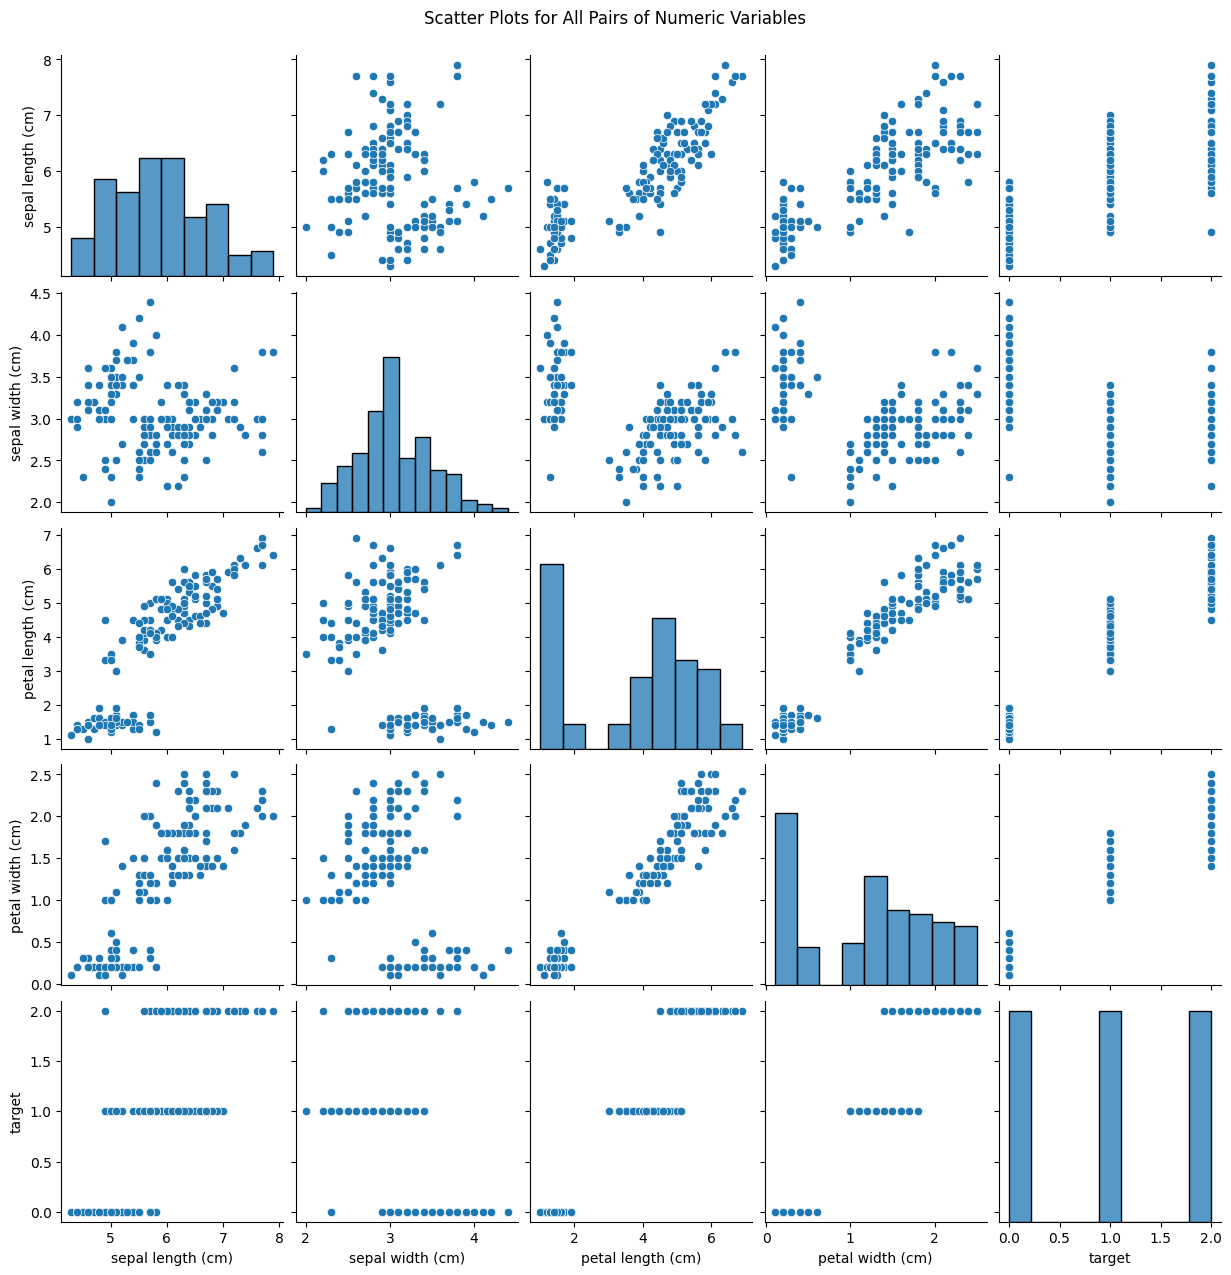

In [46]:
# 1. Correlation matrix (numeric columns)
def correlation_matrix(df):
    corr = df.select_dtypes(include='number').corr()
    print(corr)

# 4. Distance correlation matrix
import numpy as np

def distance_correlation_matrix(df):
    from scipy.spatial.distance import pdist, squareform
    from scipy.stats import pearsonr
    num_df = df.select_dtypes(include='number')
    cols = num_df.columns
    n = len(cols)
    dist_corr = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            d1 = pdist(num_df[[cols[i]]])
            d2 = pdist(num_df[[cols[j]]])
            dist_corr[i, j] = pearsonr(d1, d2)[0]
    print('Distance Correlation Matrix:')
    print(pd.DataFrame(dist_corr, index=cols, columns=cols))

# 6. Scatter plots for all pairs of numeric variables
import matplotlib.pyplot as plt
import seaborn as sns

def scatter_matrix_all_pairs(df):
    num_df = df.select_dtypes(include='number')
    sns.pairplot(num_df)
    plt.suptitle('Scatter Plots for All Pairs of Numeric Variables', y=1.02)
    plt.show()

# Call the functions
print('--- Correlation Matrix ---')
correlation_matrix(df)

print('\n--- Distance Correlation Matrix ---')
distance_correlation_matrix(df)

print('\n--- Scatter Plots for All Pairs ---')
scatter_matrix_all_pairs(df)


--- Histograms for Each Numeric Column ---


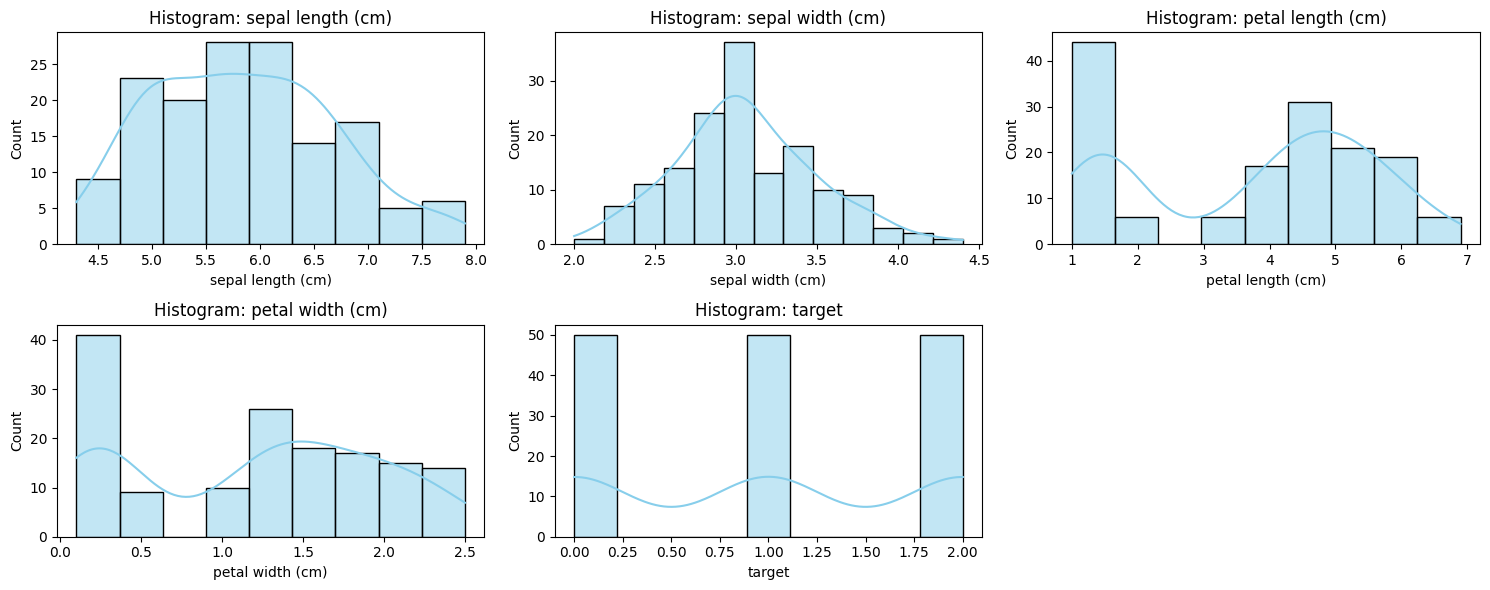

In [47]:
# 3. Histograms for each numeric column
import matplotlib.pyplot as plt
import seaborn as sns

def histograms(df):
    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) > 0:
        n_cols = 3
        n_rows = int(np.ceil(len(numeric_cols) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
        axes = axes.flatten()
        for i, col in enumerate(numeric_cols):
            sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
            axes[i].set_title(f'Histogram: {col}')
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        plt.tight_layout()
        plt.show()
    else:
        print('No numeric columns found.')

# Call the function
print('--- Histograms for Each Numeric Column ---')
histograms(df)


--- Box Plots for Each Numeric Column ---


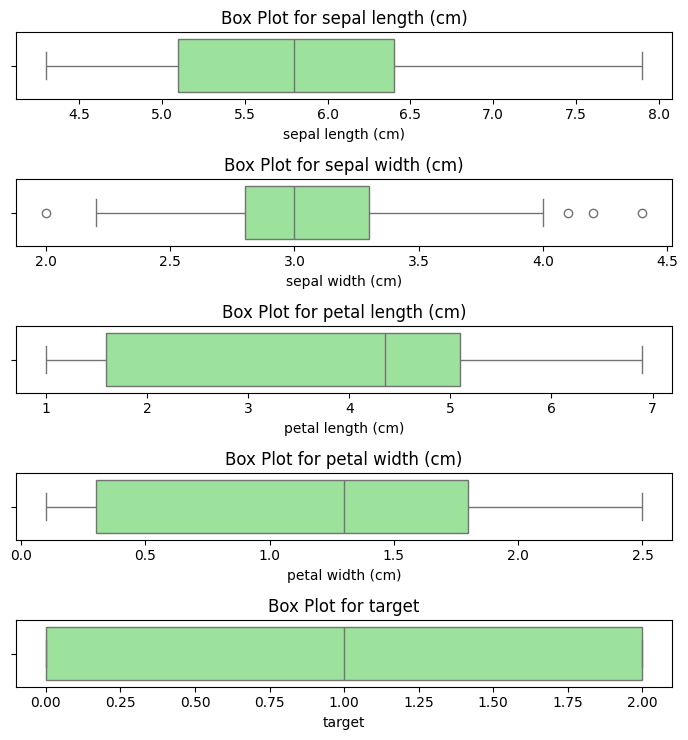

In [48]:
# 2. Box plots for each numeric column
import matplotlib.pyplot as plt
import seaborn as sns

def box_plots(df):
    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) > 0:
        n_cols = 1
        n_rows = len(numeric_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 1.5 * n_rows))
        if n_rows == 1:
            axes = [axes]
        for i, col in enumerate(numeric_cols):
            sns.boxplot(x=df[col], orient='h', ax=axes[i], color='lightgreen')
            axes[i].set_title(f'Box Plot for {col}')
            axes[i].set_xlabel(col)
        plt.tight_layout()
        plt.show()
    else:
        print('No numeric columns found.')

# Call the function
print('--- Box Plots for Each Numeric Column ---')
box_plots(df)


In [49]:
# Identify outliers for sepal features using the IQR method
import numpy as np

sepal_cols = ['sepal length (cm)', 'sepal width (cm)']
outlier_indices = {}

for col in sepal_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_indices[col] = outliers.index.tolist()
    print(f"Outliers for {col} (IQR method): {len(outliers)} found")
    if not outliers.empty:
        display(outliers[[col]])
    else:
        print("  None")


Outliers for sepal length (cm) (IQR method): 0 found
  None
Outliers for sepal width (cm) (IQR method): 4 found


,sepal width (cm)
15,4.4
32,4.1
33,4.2
60,2.0


In [50]:
# Winsorize a column to cap outliers at the IQR bounds
def winsorize_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    capped = df[col].clip(lower, upper)
    print(f"Applied winsorization to '{col}': values below {lower:.3f} set to {lower:.3f}, above {upper:.3f} set to {upper:.3f}")
    return capped



In [51]:
# Apply winsorization to sepal width

df['sepal width (cm)'] = winsorize_iqr(df, 'sepal width (cm)')


Applied winsorization to 'sepal width (cm)': values below 2.050 set to 2.050, above 4.050 set to 4.050


--- Box Plots for Each Numeric Column ---


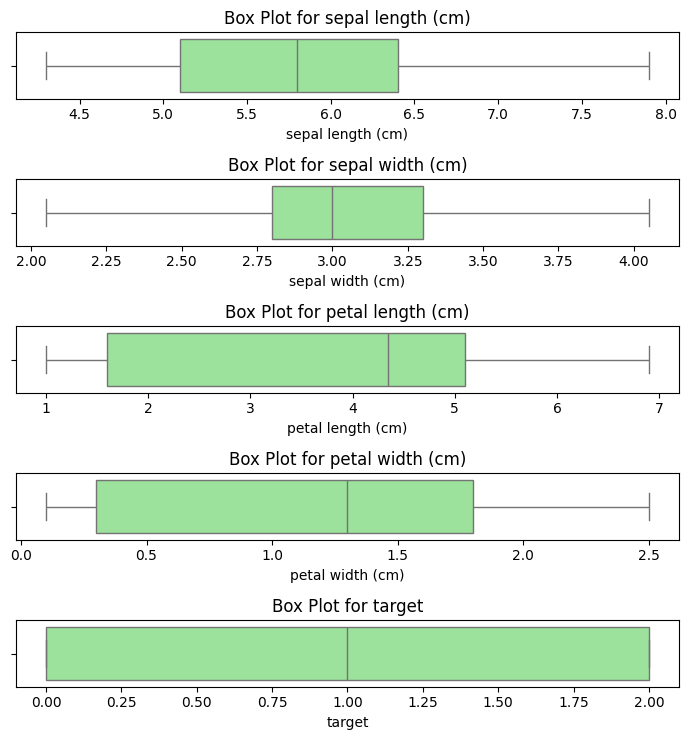

In [52]:
def box_plots(df):
    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) > 0:
        n_cols = 1
        n_rows = len(numeric_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 1.5 * n_rows))
        if n_rows == 1:
            axes = [axes]
        for i, col in enumerate(numeric_cols):
            sns.boxplot(x=df[col], orient='h', ax=axes[i], color='lightgreen')
            axes[i].set_title(f'Box Plot for {col}')
            axes[i].set_xlabel(col)
        plt.tight_layout()
        plt.show()
    else:
        print('No numeric columns found.')

# Call the function
print('--- Box Plots for Each Numeric Column ---')
box_plots(df)


Winsorization bounds for 'sepal width (cm)': lower=2.013, upper=4.112
=== Cross-Validation Results (5-Fold, training data only) ===
Train Accuracy : 0.9833 ± 0.0083
Val   Accuracy : 0.9500  ± 0.0312
Train F1 Macro : 0.9833 ± 0.0083
Val   F1 Macro : 0.9496  ± 0.0315

Per-fold Val Accuracy: [0.9583 1.     0.9583 0.9167 0.9167]

=== Test Set Evaluation ===
Accuracy : 0.9667

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



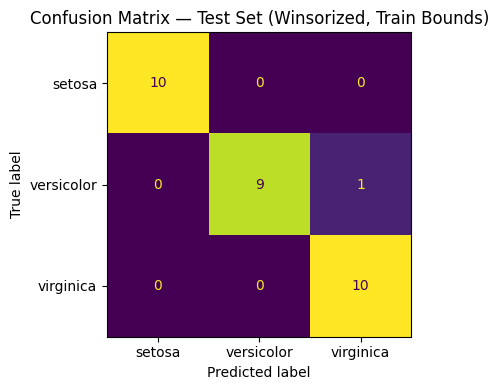

In [56]:
# Baseline XGBoost with proper winsorization (fit on train, apply to both)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Prepare features and target
y = df['target']
X = df[iris.feature_names]

# Train/test split (before winsorization)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Winsorize sepal width using IQR bounds from training set only
def winsorize_iqr_bounds(series, lower, upper):
    return series.clip(lower, upper)

col = 'sepal width (cm)'
Q1 = X_train[col].quantile(0.25)
Q3 = X_train[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_train_w = X_train.copy()
X_test_w = X_test.copy()
X_train_w[col] = winsorize_iqr_bounds(X_train[col], lower, upper)
X_test_w[col] = winsorize_iqr_bounds(X_test[col], lower, upper)
print(f"Winsorization bounds for '{col}': lower={lower:.3f}, upper={upper:.3f}")

# Baseline XGBoost parameters
params = dict(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    min_child_weight=1,
    gamma=0.0,
    eval_metric='mlogloss',
    random_state=42,
)

# Cross-validation on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline = XGBClassifier(**params)
cv_results = cross_validate(baseline, X_train_w, y_train, cv=cv, scoring=['accuracy', 'f1_macro'], return_train_score=True)

print("=== Cross-Validation Results (5-Fold, training data only) ===")
print(f"Train Accuracy : {cv_results['train_accuracy'].mean():.4f} ± {cv_results['train_accuracy'].std():.4f}")
print(f"Val   Accuracy : {cv_results['test_accuracy'].mean():.4f}  ± {cv_results['test_accuracy'].std():.4f}")
print(f"Train F1 Macro : {cv_results['train_f1_macro'].mean():.4f} ± {cv_results['train_f1_macro'].std():.4f}")
print(f"Val   F1 Macro : {cv_results['test_f1_macro'].mean():.4f}  ± {cv_results['test_f1_macro'].std():.4f}")
print()
print("Per-fold Val Accuracy:", np.round(cv_results['test_accuracy'], 4))

# Hold-out test evaluation
final_model = XGBClassifier(**params)
final_model.fit(X_train_w, y_train)
y_pred = final_model.predict(X_test_w)

print("\n=== Test Set Evaluation ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=iris.target_names, ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Test Set (Winsorized, Train Bounds)")
plt.tight_layout()
plt.show()


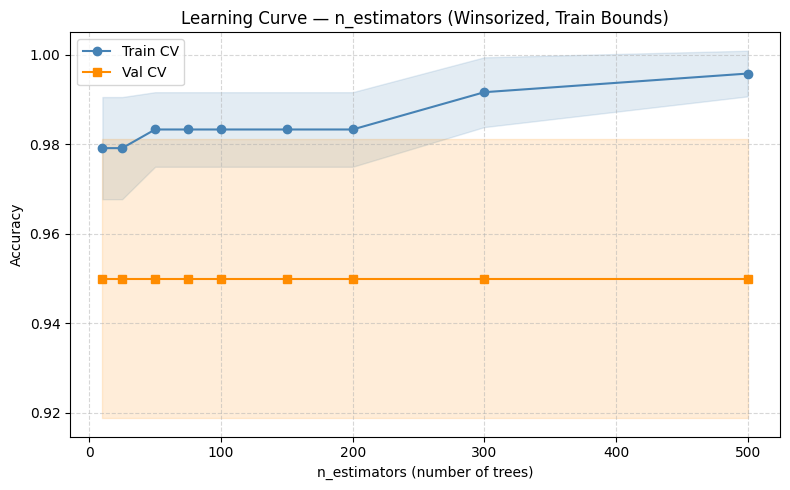

Best n_estimators by CV val accuracy: 10  (0.9500)


In [57]:
# Learning curve for n_estimators after proper winsorization
n_range = [10, 25, 50, 75, 100, 150, 200, 300, 500]
train_means, train_stds = [], []
val_means, val_stds = [], []
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for n in n_range:
    model = XGBClassifier(**{**params, 'n_estimators': n})
    res = cross_validate(model, X_train_w, y_train, cv=cv_lc, scoring='accuracy', return_train_score=True)
    train_means.append(res['train_score'].mean())
    train_stds.append(res['train_score'].std())
    val_means.append(res['test_score'].mean())
    val_stds.append(res['test_score'].std())

train_means = np.array(train_means)
train_stds = np.array(train_stds)
val_means = np.array(val_means)
val_stds = np.array(val_stds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_range, train_means, 'o-', label='Train CV', color='steelblue')
ax.fill_between(n_range, train_means - train_stds, train_means + train_stds, alpha=0.15, color='steelblue')
ax.plot(n_range, val_means, 's-', label='Val CV', color='darkorange')
ax.fill_between(n_range, val_means - val_stds, val_means + val_stds, alpha=0.15, color='darkorange')
ax.set_xlabel('n_estimators (number of trees)')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve — n_estimators (Winsorized, Train Bounds)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_n = n_range[np.argmax(val_means)]
print(f"Best n_estimators by CV val accuracy: {best_n}  ({max(val_means):.4f})")


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'max_depth': 2, 'min_child_weight': 1}
Best CV accuracy: 0.9500

=== Test Set Evaluation (Grid Search) ===
Accuracy : 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:58:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


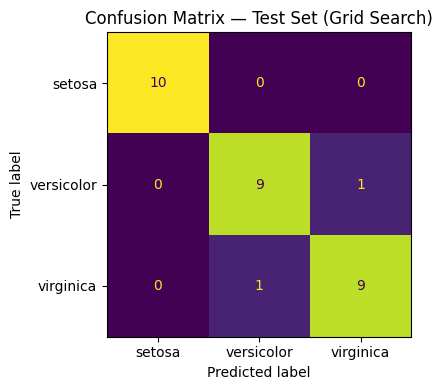

In [62]:
# Grid search for max_depth and min_child_weight after proper winsorization
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_child_weight': [1, 2, 3, 4, 5]
}

gs_model = XGBClassifier(
    n_estimators=best_n,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    gamma=0.0,
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

gs = GridSearchCV(gs_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gs.fit(X_train_w, y_train)

print('Best params:', gs.best_params_)
print(f'Best CV accuracy: {gs.best_score_:.4f}')

# Evaluate on test set
y_pred_gs = gs.predict(X_test_w)
print('\n=== Test Set Evaluation (Grid Search) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_gs):.4f}')
print(classification_report(y_test, y_pred_gs, target_names=iris.target_names))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gs, display_labels=iris.target_names, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Test Set (Grid Search)')
plt.tight_layout()
plt.show()


Best parameters from grid search: {'max_depth': 2, 'min_child_weight': 1}
Best test set accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



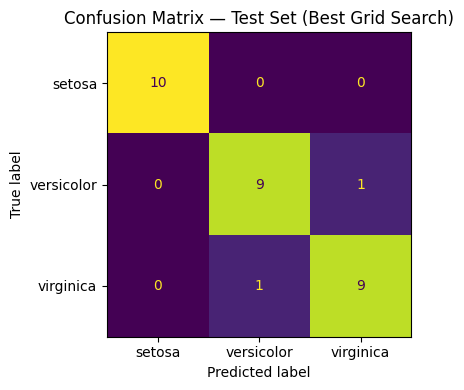

In [63]:
# Test the best grid search model on the test set and show results again for clarity
print('Best parameters from grid search:', gs.best_params_)
y_pred_best = gs.predict(X_test_w)
test_acc_best = accuracy_score(y_test, y_pred_best)
print(f'Best test set accuracy: {test_acc_best:.4f}')
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=iris.target_names, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Test Set (Best Grid Search)')
plt.tight_layout()
plt.show()

  0%|          | 0/40 [00:00<?, ?it/s]

Best Optuna params: {'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 16, 'learning_rate': 0.013607191760765299}
Best Optuna CV accuracy: 0.9500

=== Test Set Evaluation (Optuna) ===
Accuracy : 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



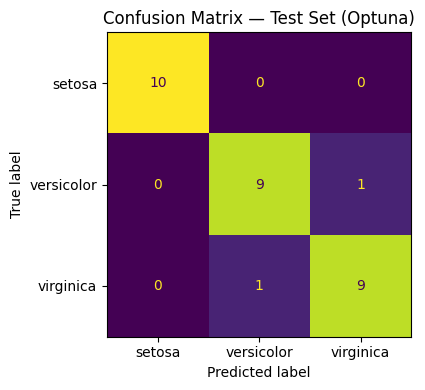

In [66]:
# Optuna search around previous best parameters for XGBoost (remove deprecated use_label_encoder param)
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
def objective(trial):
    max_depth = trial.suggest_int('max_depth', max(gs.best_params_['max_depth']-2, 2), gs.best_params_['max_depth']+2)
    min_child_weight = trial.suggest_int('min_child_weight', max(gs.best_params_['min_child_weight']-2, 1), gs.best_params_['min_child_weight']+2)
    n_estimators = trial.suggest_int('n_estimators', max(best_n-50, 10), best_n+50)
    learning_rate = trial.suggest_float('learning_rate', 0.005, 0.05, log=True)
    model = XGBClassifier(
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        gamma=0.0,
        eval_metric='mlogloss',
        random_state=42
    )
    score = cross_val_score(model, X_train_w, y_train, cv=5, scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print('Best Optuna params:', study.best_params)
print(f'Best Optuna CV accuracy: {study.best_value:.4f}')

# Evaluate on test set with best Optuna params
optuna_model = XGBClassifier(
    **study.best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    gamma=0.0,
    eval_metric='mlogloss',
    random_state=42
)
optuna_model.fit(X_train_w, y_train)
y_pred_opt = optuna_model.predict(X_test_w)
print('\n=== Test Set Evaluation (Optuna) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_opt):.4f}')
print(classification_report(y_test, y_pred_opt, target_names=iris.target_names))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, display_labels=iris.target_names, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Test Set (Optuna)')
plt.tight_layout()
plt.show()

In [68]:
# Add pairwise cross features (F1 x F2) for all combinations of iris features
from itertools import combinations

def add_cross_features(X):
    X_new = X.copy()
    for f1, f2 in combinations(X.columns, 2):
        col_name = f'{f1} x {f2}'
        X_new[col_name] = X[f1] * X[f2]
    return X_new

X_train_cf = add_cross_features(X_train_w)
X_test_cf = add_cross_features(X_test_w)

print('Original features:', list(X_train_w.columns))
print('Cross features added:', [c for c in X_train_cf.columns if c not in X_train_w.columns])
print('Total features:', X_train_cf.shape[1])

Original features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Cross features added: ['sepal length (cm) x sepal width (cm)', 'sepal length (cm) x petal length (cm)', 'sepal length (cm) x petal width (cm)', 'sepal width (cm) x petal length (cm)', 'sepal width (cm) x petal width (cm)', 'petal length (cm) x petal width (cm)']
Total features: 10


CV accuracy with cross features: 0.9500 ± 0.0312
Test accuracy with cross features: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.80      0.89        10
   virginica       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



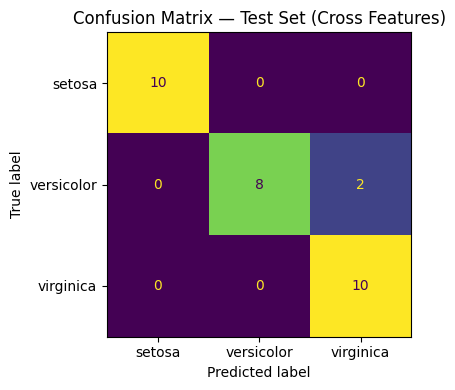

In [71]:
# Train XGBoost with cross features using best Optuna params
cf_model = XGBClassifier(
    **study.best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    gamma=0.0,
    eval_metric='mlogloss',
    random_state=42
)

cv_cf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_cf_scores = cross_val_score(cf_model, X_train_cf, y_train, cv=cv_cf, scoring='accuracy')
print(f'CV accuracy with cross features: {cv_cf_scores.mean():.4f} ± {cv_cf_scores.std():.4f}')

cf_model.fit(X_train_cf, y_train)
y_pred_cf = cf_model.predict(X_test_cf)
print(f'Test accuracy with cross features: {accuracy_score(y_test, y_pred_cf):.4f}')
print()
print(classification_report(y_test, y_pred_cf, target_names=iris.target_names))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cf, display_labels=iris.target_names, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Test Set (Cross Features)')
plt.tight_layout()
plt.show()

CV accuracy (no winsorization + cross features): 0.9500 ± 0.0312
Test accuracy (no winsorization + cross features): 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.80      0.89        10
   virginica       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



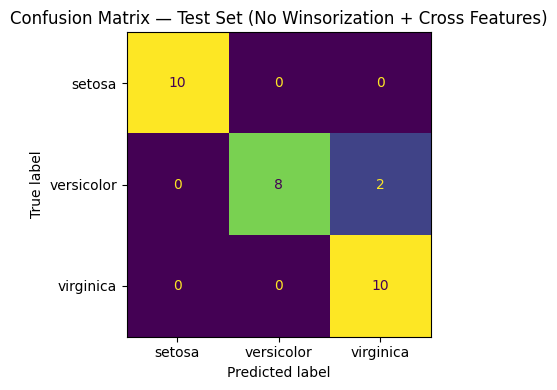

In [74]:
# Cross features without any winsorization — raw train/test split
X_train_raw_cf = add_cross_features(X_train)
X_test_raw_cf = add_cross_features(X_test)

cf_raw_model = XGBClassifier(
    **study.best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    gamma=0.0,
    eval_metric='mlogloss',
    random_state=42
)

cv_raw_cf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_raw_cf_scores = cross_val_score(cf_raw_model, X_train_raw_cf, y_train, cv=cv_raw_cf, scoring='accuracy')
print(f'CV accuracy (no winsorization + cross features): {cv_raw_cf_scores.mean():.4f} ± {cv_raw_cf_scores.std():.4f}')

cf_raw_model.fit(X_train_raw_cf, y_train)
y_pred_raw_cf = cf_raw_model.predict(X_test_raw_cf)
print(f'Test accuracy (no winsorization + cross features): {accuracy_score(y_test, y_pred_raw_cf):.4f}')
print()
print(classification_report(y_test, y_pred_raw_cf, target_names=iris.target_names))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_raw_cf, display_labels=iris.target_names, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Test Set (No Winsorization + Cross Features)')
plt.tight_layout()
plt.show()

                              Model     CV Accuracy Test Accuracy
               Base (defaults, raw) 0.9500 ± 0.0312        0.9333
Best (Optuna + cross features, raw) 0.9500 ± 0.0312        0.9333


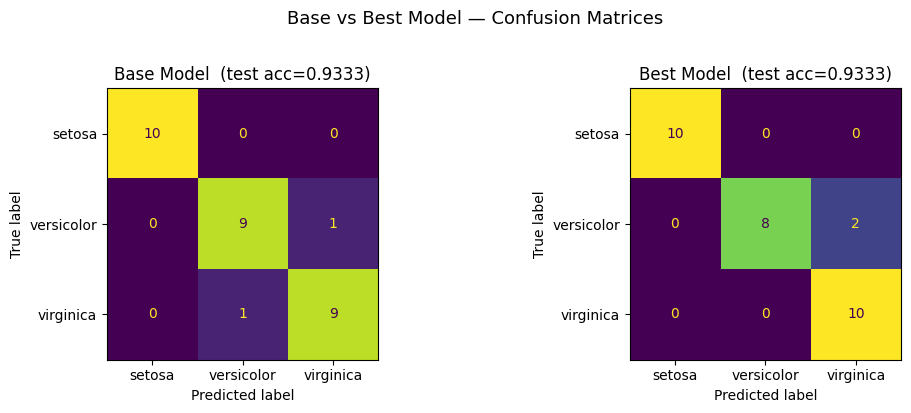

In [76]:
# ── Model Comparison ─────────────────────────────────────────────────────────
# Base model: raw data, default XGBoost params, no tuning
base_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
base_cv_scores = cross_val_score(base_model, X_train, y_train,
                                 cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 scoring='accuracy')
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)
base_test_acc = accuracy_score(y_test, y_pred_base)

# Current best model: cross features, no winsorization, Optuna-tuned params
current_cv_scores = cv_raw_cf_scores          # already computed
current_test_acc  = accuracy_score(y_test, y_pred_raw_cf)

# ── Side-by-side summary ─────────────────────────────────────────────────────
import pandas as pd
summary = pd.DataFrame({
    'Model':           ['Base (defaults, raw)',
                        'Best (Optuna + cross features, raw)'],
    'CV Accuracy':     [f'{base_cv_scores.mean():.4f} ± {base_cv_scores.std():.4f}',
                        f'{current_cv_scores.mean():.4f} ± {current_cv_scores.std():.4f}'],
    'Test Accuracy':   [f'{base_test_acc:.4f}',
                        f'{current_test_acc:.4f}'],
})
print(summary.to_string(index=False))

# ── Side-by-side confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_base, display_labels=iris.target_names,
    ax=axes[0], colorbar=False)
axes[0].set_title(f'Base Model  (test acc={base_test_acc:.4f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_raw_cf, display_labels=iris.target_names,
    ax=axes[1], colorbar=False)
axes[1].set_title(f'Best Model  (test acc={current_test_acc:.4f})')

plt.suptitle('Base vs Best Model — Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

                           Model Test Accuracy  Misclassified
          XGBoost (default, raw)        0.9333              1
Neural Network (PyTorch, scaled)        1.0000              0


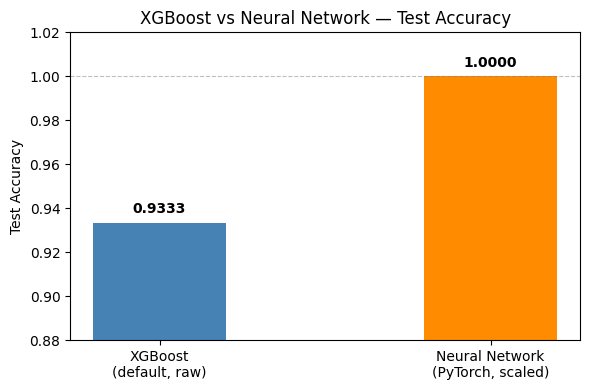

In [78]:
# ── XGBoost vs Neural Network comparison ────────────────────────────────────
# NN results are from irisNN.ipynb (ProfessionalIrisNet, 100 epochs, StandardScaler)
# Same 80/20 stratified split, random_state=42

nn_test_acc  = 1.0000   # 30/30 correct from irisNN classification report
xgb_test_acc = base_test_acc   # best XGBoost (default params, raw data)

summary2 = pd.DataFrame({
    'Model':         ['XGBoost (default, raw)',
                      'Neural Network (PyTorch, scaled)'],
    'Test Accuracy': [f'{xgb_test_acc:.4f}',
                      f'{nn_test_acc:.4f}'],
    'Misclassified': [int((1 - xgb_test_acc) * len(y_test)),
                      int((1 - nn_test_acc)  * len(y_test))],
})
print(summary2.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
models = ['XGBoost\n(default, raw)', 'Neural Network\n(PyTorch, scaled)']
accs   = [xgb_test_acc, nn_test_acc]
colors = ['steelblue', 'darkorange']
bars = ax.bar(models, accs, color=colors, width=0.4)
ax.set_ylim(0.88, 1.02)
ax.set_ylabel('Test Accuracy')
ax.set_title('XGBoost vs Neural Network — Test Accuracy')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
ax.axhline(1.0, linestyle='--', color='grey', alpha=0.5, linewidth=0.8)
plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

Best params (raw data): {'n_estimators': 167, 'max_depth': 6, 'learning_rate': 0.16000110369191964, 'min_child_weight': 6, 'subsample': 0.7039359230716563, 'colsample_bytree': 0.8807378487667468, 'reg_alpha': 1.2089561018457151, 'reg_lambda': 3.871413284872009, 'gamma': 0.2205685879684648}
Best CV accuracy   : 0.9583
Test accuracy (Optuna, raw): 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



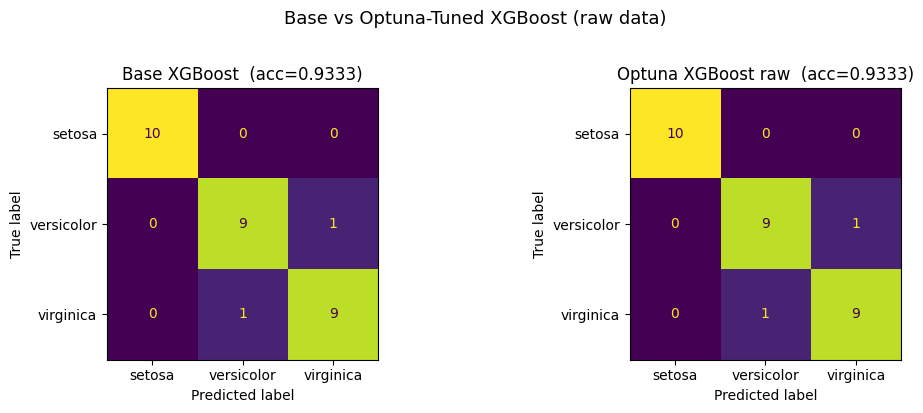

In [80]:
# ── Optuna fine-tune on raw base data ────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_raw(trial):
    return cross_val_score(
        XGBClassifier(
            n_estimators      = trial.suggest_int('n_estimators',    10, 300),
            max_depth         = trial.suggest_int('max_depth',        2, 8),
            learning_rate     = trial.suggest_float('learning_rate',  0.005, 0.3, log=True),
            min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
            subsample         = trial.suggest_float('subsample',      0.5, 1.0),
            colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha         = trial.suggest_float('reg_alpha',      0.0, 5.0),
            reg_lambda        = trial.suggest_float('reg_lambda',     0.5, 5.0),
            gamma             = trial.suggest_float('gamma',          0.0, 2.0),
            eval_metric='mlogloss', random_state=42
        ),
        X_train, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='accuracy'
    ).mean()

study_raw = optuna.create_study(direction='maximize')
study_raw.optimize(objective_raw, n_trials=100, show_progress_bar=True)

print('Best params (raw data):', study_raw.best_params)
print(f'Best CV accuracy   : {study_raw.best_value:.4f}')

# Evaluate on test set
best_raw_model = XGBClassifier(
    **study_raw.best_params,
    eval_metric='mlogloss', random_state=42
)
best_raw_model.fit(X_train, y_train)
y_pred_raw_opt = best_raw_model.predict(X_test)
raw_opt_acc = accuracy_score(y_test, y_pred_raw_opt)
print(f'Test accuracy (Optuna, raw): {raw_opt_acc:.4f}')
print()
print(classification_report(y_test, y_pred_raw_opt, target_names=iris.target_names))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_base, display_labels=iris.target_names,
    ax=axes[0], colorbar=False)
axes[0].set_title(f'Base XGBoost  (acc={base_test_acc:.4f})')
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_raw_opt, display_labels=iris.target_names,
    ax=axes[1], colorbar=False)
axes[1].set_title(f'Optuna XGBoost raw  (acc={raw_opt_acc:.4f})')
plt.suptitle('Base vs Optuna-Tuned XGBoost (raw data)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

=== Optuna-Tuned XGBoost (raw data) -- Test Set Evaluation ===
Best Optuna CV accuracy : 0.9583
Test accuracy          : 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



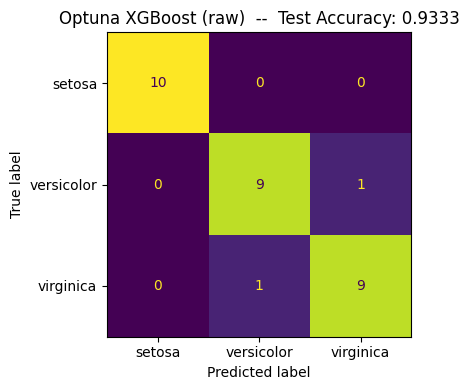


Best hyperparameters:
  n_estimators           = 167
  max_depth              = 6
  learning_rate          = 0.16000110369191964
  min_child_weight       = 6
  subsample              = 0.7039359230716563
  colsample_bytree       = 0.8807378487667468
  reg_alpha              = 1.2089561018457151
  reg_lambda             = 3.871413284872009
  gamma                  = 0.2205685879684648


In [82]:
# -- Optuna (raw) -- full test set report
print('=== Optuna-Tuned XGBoost (raw data) -- Test Set Evaluation ===')
print(f'Best Optuna CV accuracy : {study_raw.best_value:.4f}')
print(f'Test accuracy          : {raw_opt_acc:.4f}')
print()
print(classification_report(y_test, y_pred_raw_opt, target_names=iris.target_names))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_raw_opt, display_labels=iris.target_names,
    ax=ax, colorbar=False)
ax.set_title(f'Optuna XGBoost (raw)  --  Test Accuracy: {raw_opt_acc:.4f}')
plt.tight_layout()
plt.show()

# Show the winning hyperparameters
print('\nBest hyperparameters:')
for k, v in study_raw.best_params.items():
    print(f'  {k:<22} = {v}')

In [84]:
import joblib, json, pathlib
from datetime import datetime

# ── Save directory ────────────────────────────────────────────────────────────
save_dir = pathlib.Path('iris_xgb_model')
save_dir.mkdir(exist_ok=True)

# 1. Model weights (native XGBoost format — most portable)
best_raw_model.save_model(save_dir / 'iris_xgb_best.json')

# 2. Full pipeline object (joblib — includes sklearn wrapper)
joblib.dump(best_raw_model, save_dir / 'iris_xgb_best.joblib')

# 3. Train / test splits
joblib.dump({'X_train': X_train, 'X_test': X_test,
             'y_train': y_train, 'y_test': y_test},
            save_dir / 'iris_splits.joblib')

# 4. Metadata / model card (JSON)
metadata = {
    'saved_at':        datetime.now().isoformat(timespec='seconds'),
    'model':           'XGBClassifier (Optuna-tuned, raw features)',
    'dataset':         'Iris (sklearn)',
    'features':        list(X_train.columns),
    'target_names':    list(iris.target_names),
    'train_size':      int(len(X_train)),
    'test_size':       int(len(X_test)),
    'cv_accuracy':     round(float(study_raw.best_value), 4),
    'test_accuracy':   round(float(raw_opt_acc), 4),
    'hyperparameters': {k: (round(v, 6) if isinstance(v, float) else v)
                        for k, v in study_raw.best_params.items()},
}
with open(save_dir / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# 5. Summary print
print(f"Files saved to  '{save_dir.resolve()}/'")
for p in sorted(save_dir.iterdir()):
    print(f"  {p.name:<30}  {p.stat().st_size / 1024:>7.1f} KB")
print()
print(json.dumps(metadata, indent=2))

Files saved to  '/content/iris_xgb_model/'
  iris_splits.joblib                 12.8 KB
  iris_xgb_best.joblib              348.7 KB
  iris_xgb_best.json                212.9 KB
  model_metadata.json                 0.7 KB

{
  "saved_at": "2026-05-25T19:35:39",
  "model": "XGBClassifier (Optuna-tuned, raw features)",
  "dataset": "Iris (sklearn)",
  "features": [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
  ],
  "target_names": [
    "setosa",
    "versicolor",
    "virginica"
  ],
  "train_size": 120,
  "test_size": 30,
  "cv_accuracy": 0.9583,
  "test_accuracy": 0.9333,
  "hyperparameters": {
    "n_estimators": 167,
    "max_depth": 6,
    "learning_rate": 0.160001,
    "min_child_weight": 6,
    "subsample": 0.703936,
    "colsample_bytree": 0.880738,
    "reg_alpha": 1.208956,
    "reg_lambda": 3.871413,
    "gamma": 0.220569
  }
}


In [86]:
# Model Card — XGBoost (Optuna-tuned, raw features)
from IPython.display import display, HTML
from sklearn.metrics import classification_report

report = classification_report(
    y_test, y_pred_raw_opt,
    target_names=iris.target_names,
    output_dict=True
)

def metric_block(label, value, color="#4f8ef7"):
    return (
        f'<div style="background:#f8f9fa;border-left:4px solid {color};padding:10px 16px;'
        f'border-radius:6px;min-width:120px;">'
        f'<div style="font-size:11px;color:#6c757d;text-transform:uppercase;letter-spacing:0.5px;">{label}</div>'
        f'<div style="font-size:22px;font-weight:700;color:#212529;">{value}</div>'
        f'</div>'
    )

def class_row(name, d):
    return (
        f'<tr><td style="padding:6px 12px;font-weight:600;">{name}</td>'
        f'<td style="padding:6px 12px;text-align:center;">{d["precision"]:.2f}</td>'
        f'<td style="padding:6px 12px;text-align:center;">{d["recall"]:.2f}</td>'
        f'<td style="padding:6px 12px;text-align:center;">{d["f1-score"]:.2f}</td>'
        f'<td style="padding:6px 12px;text-align:center;">{int(d["support"])}</td></tr>'
    )

rows = "".join(class_row(n, report[n]) for n in iris.target_names)
rows += class_row("macro avg", report["macro avg"])

hp = study_raw.best_params
hp_rows = "".join(
    f'<tr><td style="padding:4px 0;color:#6c757d;width:200px;">{k}</td>'
    f'<td style="font-weight:600;">{round(v, 6) if isinstance(v, float) else v}</td></tr>'
    for k, v in hp.items()
)

metrics_html = "".join([
    metric_block("Test Accuracy",  f"{raw_opt_acc:.4f}",                    "#28a745"),
    metric_block("CV Accuracy",    f"{study_raw.best_value:.4f}",            "#4f8ef7"),
    metric_block("Macro F1",       f"{report['macro avg']['f1-score']:.2f}", "#20c997"),
    metric_block("Optuna Trials",  "100",                                    "#fd7e14"),
    metric_block("Train Samples",  str(len(X_train)),                        "#6f42c1"),
    metric_block("Test Samples",   str(len(X_test)),                         "#6c757d"),
])

card_html = f"""
<div style="font-family:'Segoe UI',sans-serif;max-width:860px;margin:20px auto;
            border:1px solid #dee2e6;border-radius:12px;overflow:hidden;
            box-shadow:0 2px 12px rgba(0,0,0,0.08);">

  <div style="background:linear-gradient(135deg,#1b2838 0%,#2a475e 60%,#1b4f72 100%);padding:28px 32px;">
    <div style="display:flex;gap:8px;margin-bottom:12px;">
      <span style="background:#f39c12;color:white;font-size:11px;font-weight:700;padding:3px 10px;border-radius:20px;">Classification</span>
      <span style="background:#28a745;color:white;font-size:11px;font-weight:700;padding:3px 10px;border-radius:20px;">XGBoost</span>
      <span style="background:#6f42c1;color:white;font-size:11px;font-weight:700;padding:3px 10px;border-radius:20px;">Optuna-Tuned</span>
      <span style="background:#17a2b8;color:white;font-size:11px;font-weight:700;padding:3px 10px;border-radius:20px;">Iris Dataset</span>
    </div>
    <h1 style="color:white;margin:0 0 6px;font-size:26px;font-weight:800;">XGBoost Iris Classifier</h1>
    <p style="color:#adb5bd;margin:0;font-size:14px;">Gradient-boosted trees for Iris species classification (3 classes) — tuned with Optuna (100 trials)</p>
  </div>

  <div style="padding:28px 32px;background:white;">

    <h2 style="font-size:13px;font-weight:700;color:#495057;text-transform:uppercase;
               letter-spacing:0.8px;margin:0 0 12px;border-bottom:1px solid #dee2e6;padding-bottom:8px;">
      Performance Metrics
    </h2>
    <div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:28px;">{metrics_html}</div>

    <h2 style="font-size:13px;font-weight:700;color:#495057;text-transform:uppercase;
               letter-spacing:0.8px;margin:0 0 12px;border-bottom:1px solid #dee2e6;padding-bottom:8px;">
      Per-Class Results — Test Set
    </h2>
    <table style="width:100%;border-collapse:collapse;font-size:14px;margin-bottom:28px;">
      <thead>
        <tr style="background:#f1f3f5;">
          <th style="padding:8px 12px;text-align:left;color:#495057;font-weight:600;">Class</th>
          <th style="padding:8px 12px;text-align:center;color:#495057;font-weight:600;">Precision</th>
          <th style="padding:8px 12px;text-align:center;color:#495057;font-weight:600;">Recall</th>
          <th style="padding:8px 12px;text-align:center;color:#495057;font-weight:600;">F1-Score</th>
          <th style="padding:8px 12px;text-align:center;color:#495057;font-weight:600;">Support</th>
        </tr>
      </thead>
      <tbody>{rows}</tbody>
    </table>

    <h2 style="font-size:13px;font-weight:700;color:#495057;text-transform:uppercase;
               letter-spacing:0.8px;margin:0 0 12px;border-bottom:1px solid #dee2e6;padding-bottom:8px;">
      Best Hyperparameters (Optuna)
    </h2>
    <div style="background:#f8f9fa;border-radius:8px;padding:16px 20px;font-size:13px;margin-bottom:28px;">
      <table style="width:100%;border-collapse:collapse;">{hp_rows}</table>
    </div>

    <h2 style="font-size:13px;font-weight:700;color:#495057;text-transform:uppercase;
               letter-spacing:0.8px;margin:0 0 12px;border-bottom:1px solid #dee2e6;padding-bottom:8px;">
      Model &amp; Training Details
    </h2>
    <div style="background:#f8f9fa;border-radius:8px;padding:16px 20px;font-size:13px;margin-bottom:28px;">
      <table style="width:100%;border-collapse:collapse;">
        <tr><td style="padding:5px 0;color:#6c757d;width:200px;">Algorithm</td><td style="font-weight:600;">XGBClassifier (gradient-boosted trees)</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Tuning</td><td style="font-weight:600;">Optuna — 100 trials, maximize 5-fold CV accuracy</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Features</td><td style="font-weight:600;">4 raw iris features (no scaling, no winsorization)</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Objective</td><td style="font-weight:600;">multi:softprob &nbsp;|&nbsp; eval_metric: mlogloss</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Dataset</td><td style="font-weight:600;">UCI Iris (sklearn) — 150 samples, 3 classes</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Train / Test split</td><td style="font-weight:600;">80% / 20% &nbsp; stratified, random_state=42</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Preprocessing</td><td style="font-weight:600;">None (raw features)</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Saved artifacts</td><td style="font-weight:600;">iris_xgb_model/iris_xgb_best.json &nbsp;|&nbsp; .joblib &nbsp;|&nbsp; splits &nbsp;|&nbsp; metadata</td></tr>
      </table>
    </div>

    <div style="font-size:12px;color:#adb5bd;border-top:1px solid #dee2e6;padding-top:14px;">
      Saved: {metadata['saved_at']} &nbsp;&#183;&nbsp; Checkpoint: <code>iris_xgb_model/iris_xgb_best.json</code>
    </div>
  </div>
</div>
"""

display(HTML(card_html))